# 라벨링 파이프라인 실행 결과 분석
> `label_results/reports/` 의 모든 run_report + feature_timing JSON을 시각화

In [1]:
import json, glob, os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False
try:
    matplotlib.rc('font', family='Malgun Gothic')
except:
    try:
        matplotlib.rc('font', family='AppleGothic')
    except:
        pass

REPORTS_DIR = Path('C:/Users/user/Documents/40.WhatSurf/label_results/reports')
print('reports dir:', REPORTS_DIR.resolve())
print('exists:', REPORTS_DIR.exists())
print('files:', len(list(REPORTS_DIR.glob('*.json'))))

reports dir: C:\Users\user\Documents\40.WhatSurf\label_results\reports
exists: True
files: 80


In [2]:
# ── 데이터 로드 ─────────────────────────────────────────────────────────────
run_reports = []
feature_timings = []

for path in sorted(REPORTS_DIR.glob('run_report_*.json')):
    with open(path, encoding='utf-8') as f:
        d = json.load(f)
    ts = path.stem.replace('run_report_', '')
    meta = d.get('meta', {})
    timing = d.get('timing', {})
    api = d.get('api_usage', {})
    quality = d.get('label_quality', {})

    per_feature = timing.get('per_feature', {})
    features_run = list(per_feature.keys())

    row = {
        'ts': ts,
        'keyword': meta.get('keyword', ''),
        'batch_size': meta.get('batch_size', 0),
        'n_articles': meta.get('total_articles', 0),
        'n_comments': meta.get('total_comments', 0),
        'elapsed_sec': meta.get('total_elapsed_sec', 0),
        'started_at': meta.get('started_at', ''),
        'throughput_per_min': timing.get('overall_throughput_per_min', 0),
        'features_run': ', '.join(features_run),
        'n_features': len(features_run),
        'groq_calls': api.get('calls', {}).get('groq', 0),
        'gemini_calls': api.get('calls', {}).get('gemini_pro', 0),
        'groq_retries': api.get('retries', {}).get('groq', 0),
        'key_rotations': api.get('key_rotation_count', 0),
        'errors': len(api.get('errors', [])),
    }
    # 피처별 세부 타이밍
    for feat, fdata in per_feature.items():
        row[f'{feat}_mean_sec'] = fdata.get('mean_sec_per_item', 0)
        row[f'{feat}_total_sec'] = fdata.get('total_sec', 0)
        row[f'{feat}_tpm'] = fdata.get('throughput_per_min', 0)

    run_reports.append(row)

df = pd.DataFrame(run_reports)
df['elapsed_min'] = df['elapsed_sec'] / 60
df['sec_per_article'] = df['elapsed_sec'] / df['n_articles'].replace(0, float('nan'))
print(f'총 {len(df)}개 런 로드 완료')
df[['ts','keyword','batch_size','n_articles','elapsed_min','throughput_per_min','n_features','features_run']]

총 16개 런 로드 완료


,ts,keyword,batch_size,n_articles,elapsed_min,throughput_per_min,n_features,features_run
0,20260322_001805,최순실 국정농단,5,50,21.676667,11.5,5,"stance, loaded_words, frame_logic, bias, omission"
1,20260322_004856,방탄 광화문,20,50,18.175833,13.8,5,"stance, loaded_words, frame_logic, bias, omission"
2,20260322_133301,삼성전자 주가,100,577,29.349333,19.7,1,omission
3,20260322_143305,3,100,82,2.082000,196.9,5,"stance, loaded_words, frame_logic, bias, omission"
4,20260322_144430,3,100,82,2.454000,167.1,5,"stance, loaded_words, frame_logic, bias, omission"
5,20260322_145705,3,100,82,6.526667,25.1,2,"omission, frame_logic"
6,20260322_151632,3,100,82,7.835667,52.3,5,"stance, loaded_words, frame_logic, omission, bias"
7,20260322_153322,3,100,82,7.176333,57.1,5,"stance, loaded_words, omission, frame_logic, bias"
8,20260322_155220,4,100,86,7.081833,60.7,5,"stance, loaded_words, omission, frame_logic, bias"
9,20260322_160509,4,100,86,0.132333,649.9,1,frame_logic


## 1. 전체 런 요약 테이블

In [3]:
summary = df[['ts','keyword','batch_size','n_articles','elapsed_min','sec_per_article',
              'throughput_per_min','n_features','groq_calls','gemini_calls',
              'groq_retries','key_rotations','errors']].copy()
summary.columns = ['시각','키워드','배치크기','기사수','소요(분)',
                    '초/건','건/분','피처수','Groq호출','Gemini호출',
                    'Groq재시도','키로테이션','에러']
summary['소요(분)'] = summary['소요(분)'].round(1)
summary['초/건'] = summary['초/건'].round(1)
summary['건/분'] = summary['건/분'].round(1)

pd.set_option('display.max_colwidth', 25)
pd.set_option('display.width', 120)
summary

,시각,키워드,배치크기,기사수,소요(분),초/건,건/분,피처수,Groq호출,Gemini호출,Groq재시도,키로테이션,에러
0,20260322_001805,최순실 국정농단,5,50,21.7,26.0,11.5,5,15,10,5,6,5
1,20260322_004856,방탄 광화문,20,50,18.2,21.8,13.8,5,6,3,0,7,0
2,20260322_133301,삼성전자 주가,100,577,29.3,3.1,19.7,1,0,6,0,5,0
3,20260322_143305,3,100,82,2.1,1.5,196.9,5,2,1,0,1,0
4,20260322_144430,3,100,82,2.5,1.8,167.1,5,2,1,0,1,0
5,20260322_145705,3,100,82,6.5,4.8,25.1,2,0,1,1,7,1
6,20260322_151632,3,100,82,7.8,5.7,52.3,5,1,1,1,7,1
7,20260322_153322,3,100,82,7.2,5.3,57.1,5,0,1,2,7,2
8,20260322_155220,4,100,86,7.1,4.9,60.7,5,0,1,2,7,2
9,20260322_160509,4,100,86,0.1,0.1,649.9,1,1,0,0,0,0


## 2. batch_size 변화에 따른 처리 성능 비교
> 동일 규모(50건 전후) + 전체 피처 실행 런만 추출

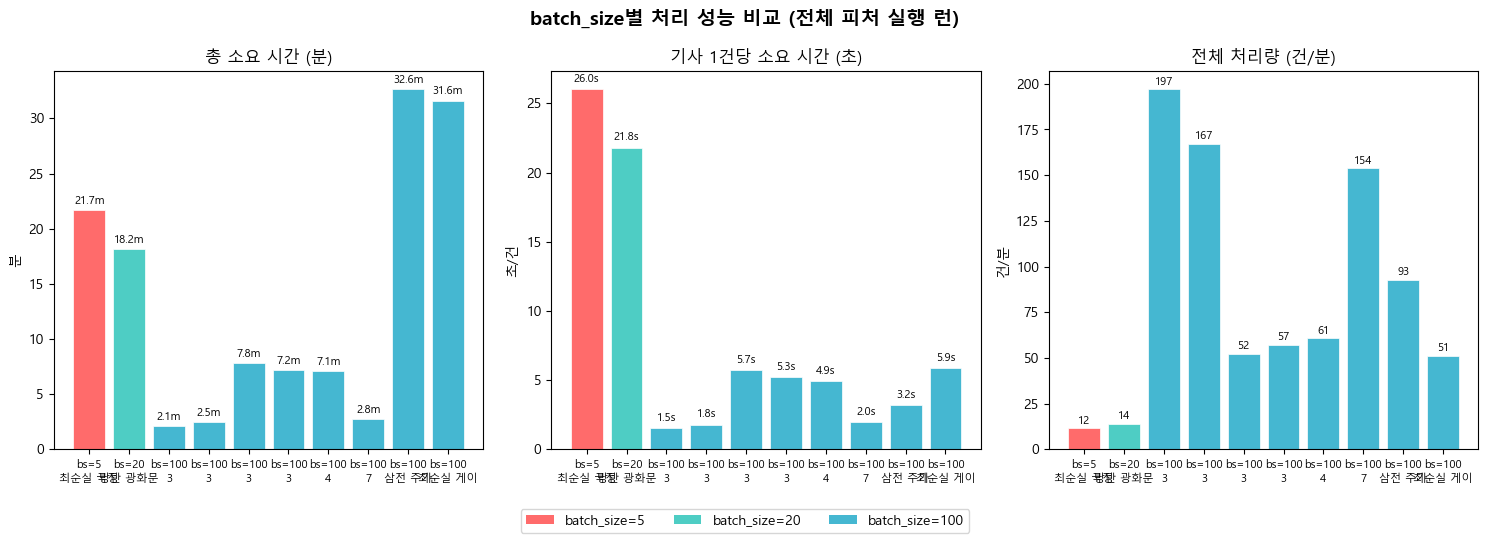

In [4]:
# 전체 피처(5개) 실행한 런만
full_runs = df[df['n_features'] == 5].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('batch_size별 처리 성능 비교 (전체 피처 실행 런)', fontsize=14, fontweight='bold')

colors = ['#FF6B6B' if b == 5 else '#4ECDC4' if b == 20 else '#45B7D1'
          for b in full_runs['batch_size']]
labels = [f"{row['키워드']}\n(bs={row['배치크기']})" 
          for _, row in full_runs[['keyword','batch_size']].rename(columns={'keyword':'키워드','batch_size':'배치크기'}).iterrows()]
x = range(len(full_runs))

# 소요 시간
ax = axes[0]
bars = ax.bar(x, full_runs['elapsed_min'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('총 소요 시간 (분)')
ax.set_xticks(x)
ax.set_xticklabels([f"bs={b}\n{k[:6]}" for b,k in zip(full_runs['batch_size'], full_runs['keyword'])], fontsize=8)
ax.set_ylabel('분')
for bar, val in zip(bars, full_runs['elapsed_min']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}m', ha='center', va='bottom', fontsize=8)

# 기사당 처리 시간
ax = axes[1]
bars = ax.bar(x, full_runs['sec_per_article'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('기사 1건당 소요 시간 (초)')
ax.set_xticks(x)
ax.set_xticklabels([f"bs={b}\n{k[:6]}" for b,k in zip(full_runs['batch_size'], full_runs['keyword'])], fontsize=8)
ax.set_ylabel('초/건')
for bar, val in zip(bars, full_runs['sec_per_article']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}s', ha='center', va='bottom', fontsize=8)

# 전체 처리량
ax = axes[2]
bars = ax.bar(x, full_runs['throughput_per_min'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('전체 처리량 (건/분)')
ax.set_xticks(x)
ax.set_xticklabels([f"bs={b}\n{k[:6]}" for b,k in zip(full_runs['batch_size'], full_runs['keyword'])], fontsize=8)
ax.set_ylabel('건/분')
for bar, val in zip(bars, full_runs['throughput_per_min']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6B6B', label='batch_size=5'),
                   Patch(facecolor='#4ECDC4', label='batch_size=20'),
                   Patch(facecolor='#45B7D1', label='batch_size=100')]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

## 3. 피처별 처리 시간 분석

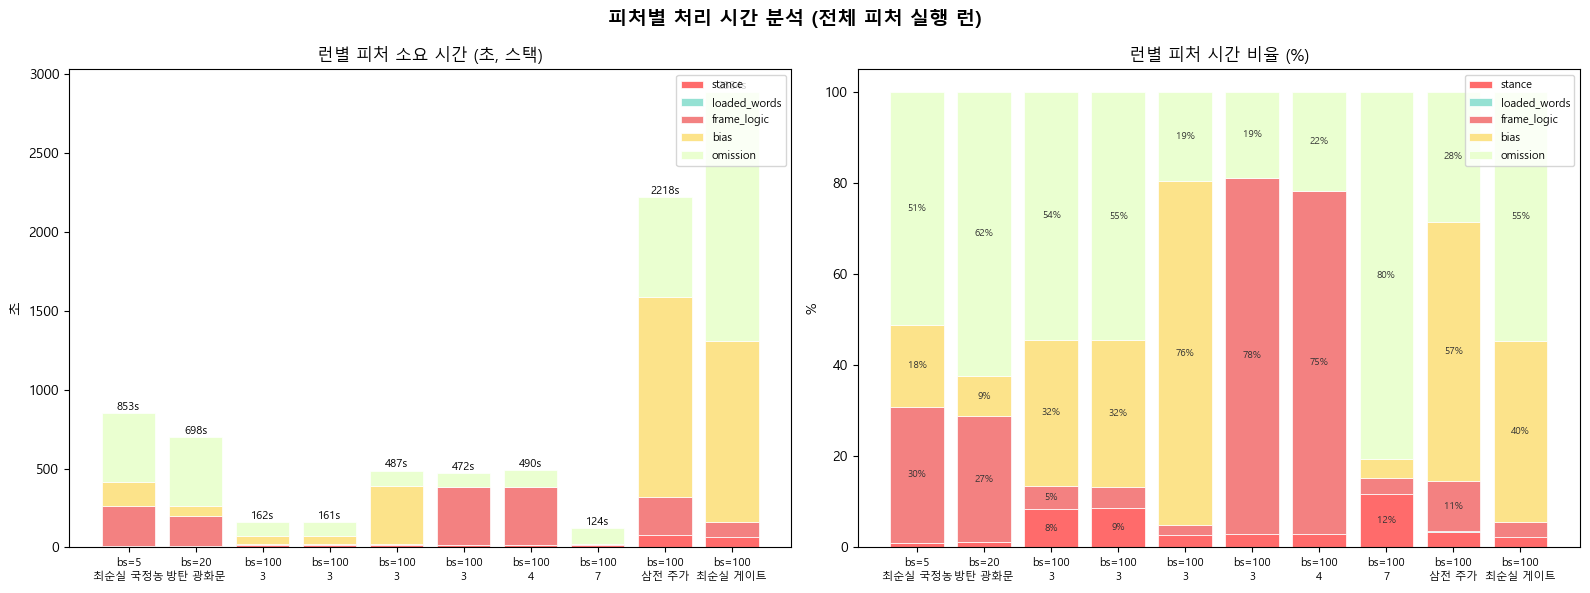

In [5]:
# 전체 피처 런에서 피처별 total_sec 비교
feat_cols_sec = [c for c in df.columns if c.endswith('_total_sec')]
feat_names = [c.replace('_total_sec','') for c in feat_cols_sec]

feat_df = full_runs[['ts','keyword','batch_size'] + feat_cols_sec].copy()
feat_df.columns = ['ts','keyword','batch_size'] + feat_names
feat_df = feat_df.fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('피처별 처리 시간 분석 (전체 피처 실행 런)', fontsize=14, fontweight='bold')

# 스택드 바차트 — 절대 시간(초)
ax = axes[0]
feat_colors = {'stance':'#FF6B6B', 'loaded_words':'#95E1D3',
               'frame_logic':'#F38181', 'bias':'#FCE38A', 'omission':'#EAFFD0'}
bottom = np.zeros(len(feat_df))
x = range(len(feat_df))
run_labels = [f"bs={b}\n{k[:7]}" for b, k in zip(feat_df['batch_size'], feat_df['keyword'])]

for feat in feat_names:
    if feat in feat_df.columns:
        vals = feat_df[feat].values
        color = feat_colors.get(feat, '#999')
        ax.bar(x, vals, bottom=bottom, label=feat, color=color, edgecolor='white', linewidth=0.5)
        bottom += vals

ax.set_title('런별 피처 소요 시간 (초, 스택)')
ax.set_xticks(x)
ax.set_xticklabels(run_labels, fontsize=8)
ax.set_ylabel('초')
ax.legend(loc='upper right', fontsize=8)
for i, total in enumerate(bottom):
    ax.text(i, total + 1, f'{total:.0f}s', ha='center', va='bottom', fontsize=8)

# 비율 100% 스택 바차트
ax = axes[1]
row_totals = feat_df[feat_names].sum(axis=1).replace(0, float('nan'))
pct_df = feat_df[feat_names].div(row_totals, axis=0) * 100
bottom = np.zeros(len(pct_df))

for feat in feat_names:
    if feat in pct_df.columns:
        vals = pct_df[feat].fillna(0).values
        color = feat_colors.get(feat, '#999')
        bars = ax.bar(x, vals, bottom=bottom, label=feat, color=color, edgecolor='white', linewidth=0.5)
        # 5% 이상만 레이블
        for i, (bar, v) in enumerate(zip(bars, vals)):
            if v > 5:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bottom[i] + v/2,
                        f'{v:.0f}%', ha='center', va='center', fontsize=7, color='#333')
        bottom += vals

ax.set_title('런별 피처 시간 비율 (%)')
ax.set_xticks(x)
ax.set_xticklabels(run_labels, fontsize=8)
ax.set_ylabel('%')
ax.set_ylim(0, 105)
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 4. 피처별 처리 속도 (건/분) — 단독 vs 전체 실행 비교

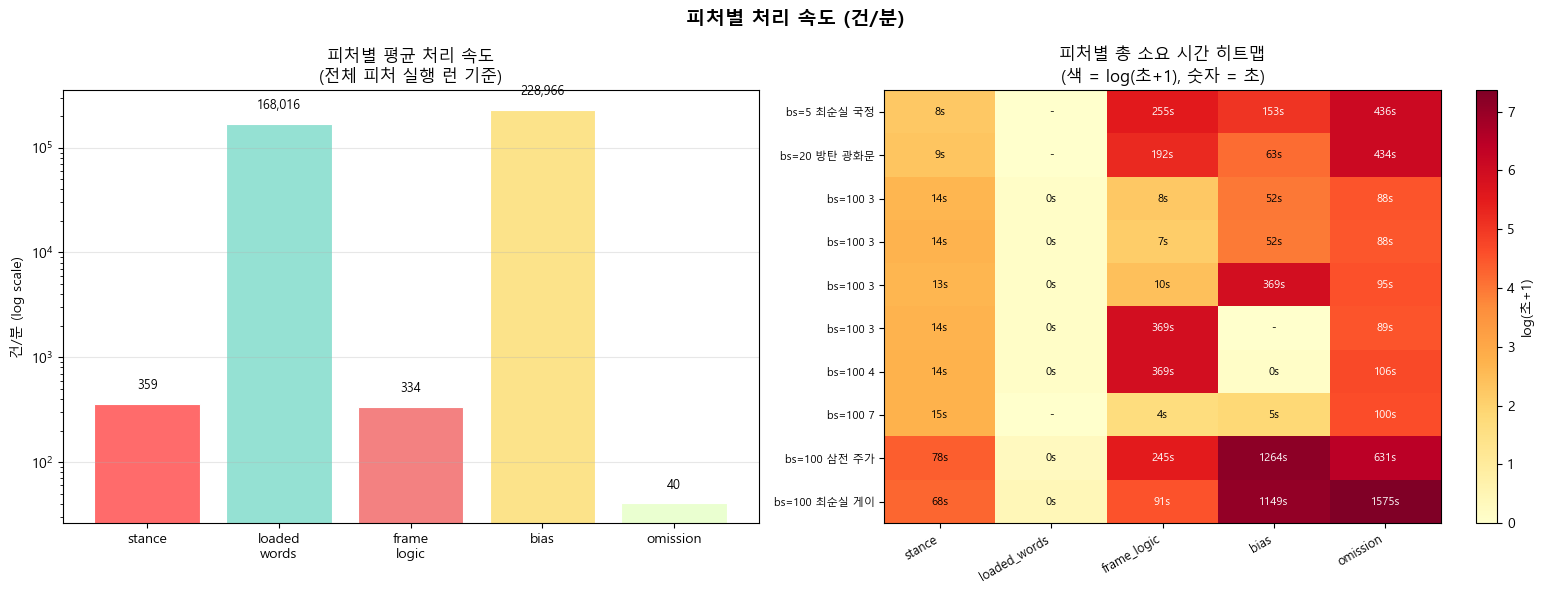

In [6]:
# 피처별 throughput 비교 (전체 피처 런 vs 단독 런)
feat_tpm_cols = [c for c in df.columns if c.endswith('_tpm')]
feat_tpm_names = [c.replace('_tpm','') for c in feat_tpm_cols]

# 전체 피처 런 평균 tpm
full_tpm = full_runs[feat_tpm_cols].mean()

# 단독 피처 런 (n_features==1)
solo_runs = df[df['n_features'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('피처별 처리 속도 (건/분)', fontsize=14, fontweight='bold')

# 전체 피처 런 기준 피처별 tpm
ax = axes[0]
tpm_vals = [full_tpm.get(f'{f}_tpm', 0) for f in feat_tpm_names]
feat_labels = [f.replace('_', '\n') for f in feat_tpm_names]
bar_colors = [feat_colors.get(f, '#999') for f in feat_tpm_names]

bars = ax.bar(feat_labels, tpm_vals, color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_title('피처별 평균 처리 속도\n(전체 피처 실행 런 기준)')
ax.set_ylabel('건/분 (log scale)')
ax.set_yscale('log')
for bar, val in zip(bars, tpm_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
                f'{val:,.0f}', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 전체 피처 런별 기사당 소요 시간 히트맵
ax = axes[1]
heat_data = []
heat_labels = []
for _, row in full_runs.iterrows():
    vals = []
    for f in feat_tpm_names:
        total_sec = row.get(f'{f}_total_sec', 0)
        vals.append(round(total_sec, 1))
    heat_data.append(vals)
    heat_labels.append(f"bs={int(row['batch_size'])} {row['keyword'][:6]}")

heat_arr = np.array(heat_data, dtype=float)
# log scale 히트맵
heat_log = np.log1p(heat_arr)
im = ax.imshow(heat_log, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(feat_tpm_names)))
ax.set_xticklabels(feat_tpm_names, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(heat_labels)))
ax.set_yticklabels(heat_labels, fontsize=8)
ax.set_title('피처별 총 소요 시간 히트맵\n(색 = log(초+1), 숫자 = 초)')

for i in range(len(heat_data)):
    for j in range(len(feat_tpm_names)):
        v = heat_arr[i, j]
        text_color = 'white' if heat_log[i, j] > heat_log.max() * 0.6 else 'black'
        ax.text(j, i, f'{v:.0f}s' if v > 0 else '-',
                ha='center', va='center', fontsize=8, color=text_color)

plt.colorbar(im, ax=ax, label='log(초+1)')
plt.tight_layout()
plt.show()

## 5. API 사용 현황

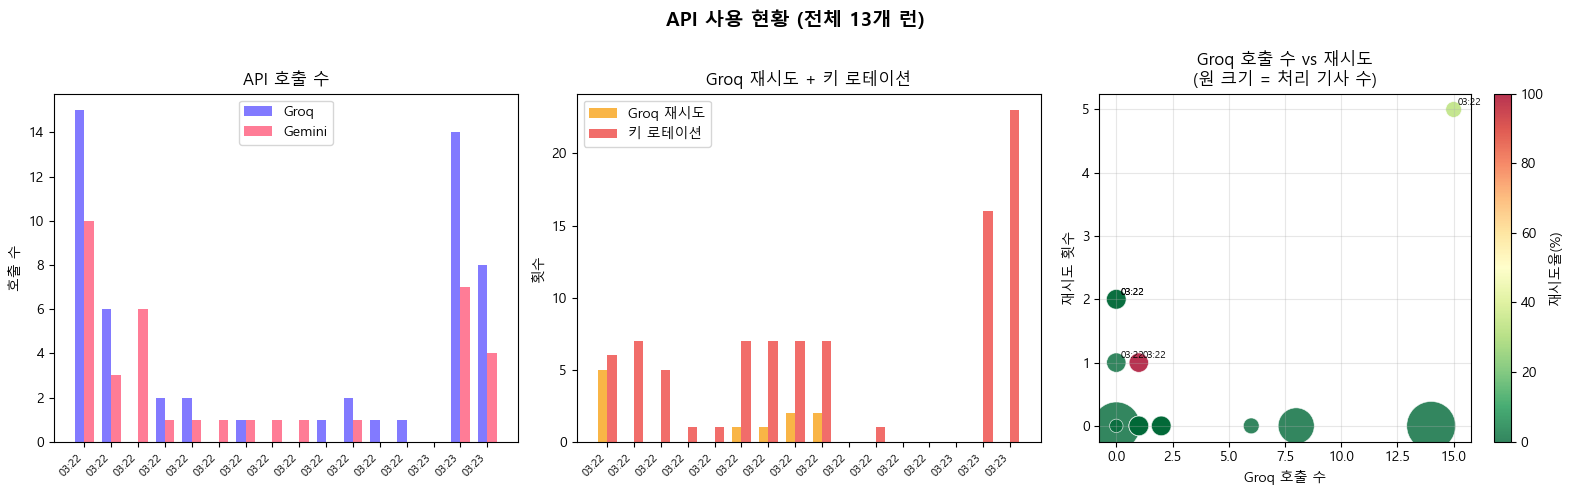

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('API 사용 현황 (전체 13개 런)', fontsize=14, fontweight='bold')

run_ids = [f"{r['ts'][4:6]}:{r['ts'][6:8]}" for r in run_reports]

# Groq vs Gemini 호출 수
ax = axes[0]
x = np.arange(len(df))
w = 0.35
b1 = ax.bar(x - w/2, df['groq_calls'], w, label='Groq', color='#6C63FF', alpha=0.85)
b2 = ax.bar(x + w/2, df['gemini_calls'], w, label='Gemini', color='#FF6584', alpha=0.85)
ax.set_title('API 호출 수')
ax.set_xticks(x)
ax.set_xticklabels(run_ids, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.set_ylabel('호출 수')

# 재시도 및 키 로테이션
ax = axes[1]
b3 = ax.bar(x - w/2, df['groq_retries'], w, label='Groq 재시도', color='#F9A825', alpha=0.85)
b4 = ax.bar(x + w/2, df['key_rotations'], w, label='키 로테이션', color='#EF5350', alpha=0.85)
ax.set_title('Groq 재시도 + 키 로테이션')
ax.set_xticks(x)
ax.set_xticklabels(run_ids, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.set_ylabel('횟수')

# Groq 재시도율 vs 호출 수
ax = axes[2]
retry_rate = (df['groq_retries'] / df['groq_calls'].replace(0, float('nan')) * 100).fillna(0)
scatter = ax.scatter(df['groq_calls'], df['groq_retries'],
                     c=retry_rate, cmap='RdYlGn_r',
                     s=df['n_articles'] * 2 + 30,
                     alpha=0.8, edgecolors='white', linewidth=0.5)
plt.colorbar(scatter, ax=ax, label='재시도율(%)')
ax.set_title('Groq 호출 수 vs 재시도\n(원 크기 = 처리 기사 수)')
ax.set_xlabel('Groq 호출 수')
ax.set_ylabel('재시도 횟수')
for i, (_, row) in enumerate(df.iterrows()):
    if row['groq_retries'] > 0:
        ax.annotate(run_ids[i],
                   (row['groq_calls'], row['groq_retries']),
                   fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 처리 속도 개선 타임라인

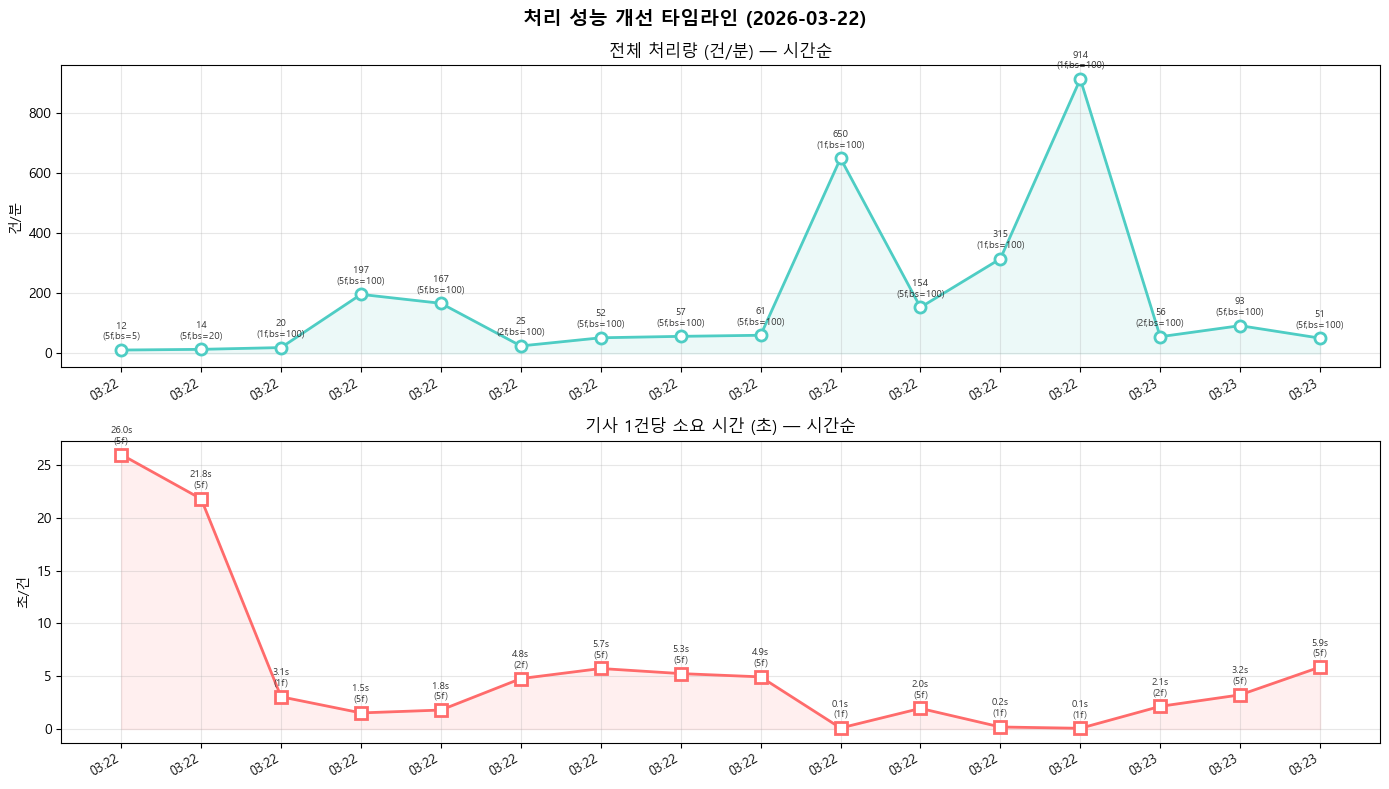

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('처리 성능 개선 타임라인 (2026-03-22)', fontsize=14, fontweight='bold')

time_labels = [f"{r['ts'][4:6]}:{r['ts'][6:8]}" for r in run_reports]

# 전체 처리량
ax = axes[0]
line = ax.plot(range(len(df)), df['throughput_per_min'], 'o-',
               color='#4ECDC4', linewidth=2, markersize=8, markerfacecolor='white',
               markeredgewidth=2)
ax.fill_between(range(len(df)), df['throughput_per_min'], alpha=0.1, color='#4ECDC4')
ax.set_title('전체 처리량 (건/분) — 시간순')
ax.set_xticks(range(len(df)))
ax.set_xticklabels(time_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('건/분')
ax.grid(alpha=0.3)
# 주요 포인트 레이블
for i, (val, feat, bs) in enumerate(zip(df['throughput_per_min'], df['n_features'], df['batch_size'])):
    ax.annotate(f'{val:.0f}\n({feat}f,bs={int(bs)})',
                (i, val), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=7, color='#333')

# 기사당 소요 시간
ax = axes[1]
line2 = ax.plot(range(len(df)), df['sec_per_article'], 's-',
                color='#FF6B6B', linewidth=2, markersize=8, markerfacecolor='white',
                markeredgewidth=2)
ax.fill_between(range(len(df)), df['sec_per_article'], alpha=0.1, color='#FF6B6B')
ax.set_title('기사 1건당 소요 시간 (초) — 시간순')
ax.set_xticks(range(len(df)))
ax.set_xticklabels(time_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('초/건')
ax.grid(alpha=0.3)
for i, (val, feat) in enumerate(zip(df['sec_per_article'], df['n_features'])):
    ax.annotate(f'{val:.1f}s\n({feat}f)',
                (i, val), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=7, color='#333')

plt.tight_layout()
plt.show()

## 7. 레이블 분포 분석

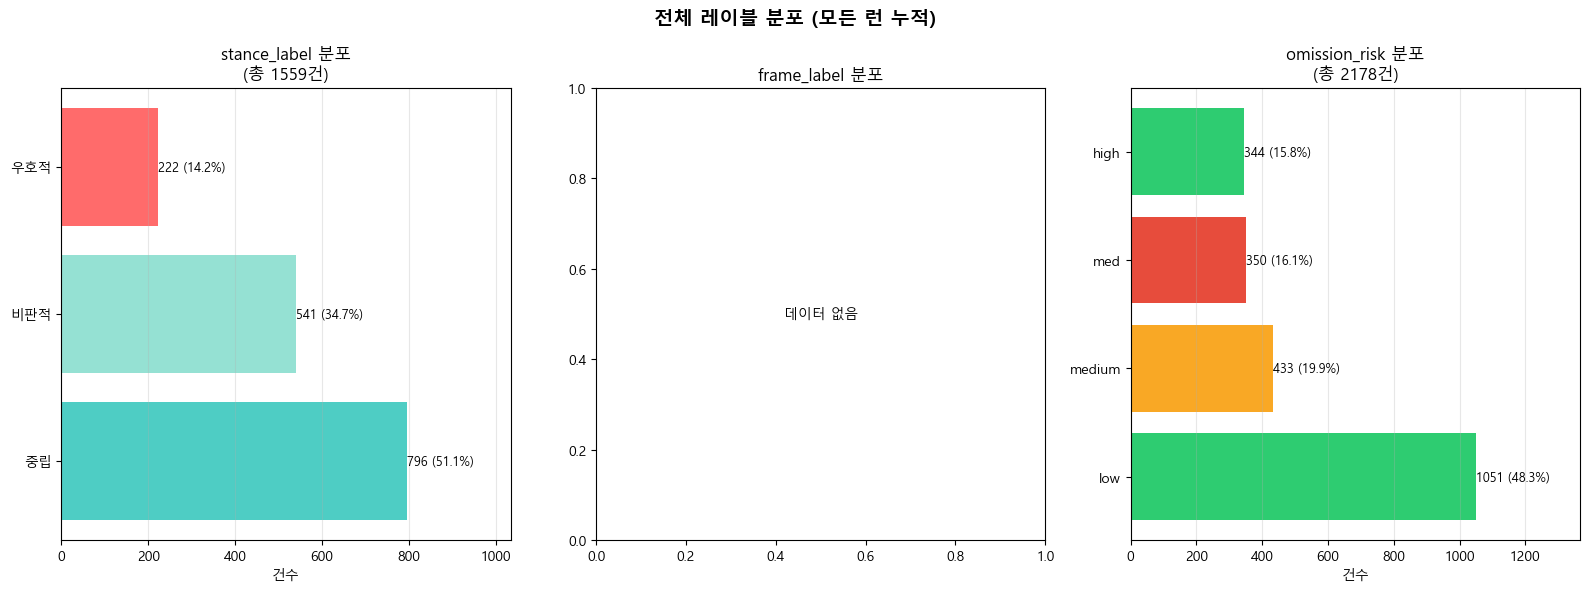

In [9]:
# label_dist 파일 로드
label_dists = []
for path in sorted(REPORTS_DIR.glob('label_dist_*.json')):
    with open(path, encoding='utf-8') as f:
        d = json.load(f)
    ts = path.stem.replace('label_dist_', '')
    d['ts'] = ts
    label_dists.append(d)

# run_report에서 label_quality > distribution 사용
all_stance = {}
all_frame = {}
all_omission = {}

for path in sorted(REPORTS_DIR.glob('run_report_*.json')):
    with open(path, encoding='utf-8') as f:
        d = json.load(f)
    quality = d.get('label_quality', {})
    dist = quality.get('distribution', {})
    
    if 'stance_label' in dist:
        for label, info in dist['stance_label'].items():
            all_stance[label] = all_stance.get(label, 0) + info['count']
    if 'frame_label' in dist:
        for label, info in dist['frame_label'].items():
            all_frame[label] = all_frame.get(label, 0) + info['count']
    if 'omission_risk' in dist:
        for label, info in dist['omission_risk'].items():
            all_omission[label] = all_omission.get(label, 0) + info['count']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('전체 레이블 분포 (모든 런 누적)', fontsize=14, fontweight='bold')

def plot_pie_or_bar(ax, data_dict, title, colors_list=None):
    if not data_dict:
        ax.text(0.5, 0.5, '데이터 없음', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return
    labels = list(data_dict.keys())
    values = list(data_dict.values())
    total = sum(values)
    sorted_pairs = sorted(zip(labels, values), key=lambda x: -x[1])
    labels, values = zip(*sorted_pairs)
    
    bars = ax.barh(labels, values,
                   color=colors_list[:len(labels)] if colors_list else None)
    ax.set_title(f'{title}\n(총 {total}건)')
    ax.set_xlabel('건수')
    for bar, val in zip(bars, values):
        pct = val/total*100
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val} ({pct:.1f}%)', va='center', fontsize=9)
    ax.set_xlim(0, max(values) * 1.3)
    ax.grid(axis='x', alpha=0.3)

plot_pie_or_bar(axes[0], all_stance, 'stance_label 분포',
                ['#4ECDC4', '#95E1D3', '#FF6B6B'])
plot_pie_or_bar(axes[1], all_frame, 'frame_label 분포',
                ['#6C63FF','#FF6584','#F9A825','#4ECDC4','#95A5A6','#E74C3C','#2ECC71'])
plot_pie_or_bar(axes[2], all_omission, 'omission_risk 분포',
                ['#2ECC71', '#F9A825', '#E74C3C'])

plt.tight_layout()
plt.show()

## 8. 핵심 수치 요약

In [10]:
print('=' * 60)
print('  핵심 수치 요약')
print('=' * 60)

print(f"\n📦 전체 런: {len(df)}회  |  총 처리 기사: {df['n_articles'].sum()}건")
print(f"   분석 기간: 2026-03-22 00:18 ~ 16:32")

print(f"\n⏱  처리 속도 범위")
print(f"   최소 처리량: {df['throughput_per_min'].min():.1f} 건/분  ({df.loc[df['throughput_per_min'].idxmin(), 'ts'][4:8]} 런)")
print(f"   최대 처리량: {df['throughput_per_min'].max():.1f} 건/분  ({df.loc[df['throughput_per_min'].idxmax(), 'ts'][4:8]} 런)")

print(f"\n🔢 batch_size별 평균 처리 속도 (전체 피처 런)")
for bs, grp in full_runs.groupby('batch_size'):
    print(f"   batch_size={bs:3d}: 평균 {grp['sec_per_article'].mean():.1f}초/건  " +
          f"({grp['throughput_per_min'].mean():.1f} 건/분)  [{len(grp)}회]")

print(f"\n🤖 API 사용 (전체)")
print(f"   Groq 총 호출: {df['groq_calls'].sum()}회  재시도: {df['groq_retries'].sum()}회  " +
      f"(재시도율 {df['groq_retries'].sum()/max(df['groq_calls'].sum(),1)*100:.1f}%)")
print(f"   Gemini 총 호출: {df['gemini_calls'].sum()}회")
print(f"   키 로테이션 총: {df['key_rotations'].sum()}회")

print(f"\n🏆 피처별 처리 속도 (전체 피처 런 평균)")
for feat in feat_tpm_names:
    col = f'{feat}_tpm'
    if col in full_runs.columns:
        avg = full_runs[col].replace(0, float('nan')).mean()
        if avg > 0:
            avg_sec = 60/avg
            print(f"   {feat:<15}: {avg:>10,.0f} 건/분  ({avg_sec:.3f}초/건)")

print()
print('   ※ loaded_words는 규칙 기반이라 LLM 대비 압도적으로 빠름')
print('   ※ omission은 Gemini Pro 사용으로 단연 가장 느림')

  핵심 수치 요약

📦 전체 런: 16회  |  총 처리 기사: 2474건
   분석 기간: 2026-03-22 00:18 ~ 16:32

⏱  처리 속도 범위
   최소 처리량: 11.5 건/분  (0322 런)
   최대 처리량: 914.0 건/분  (0322 런)

🔢 batch_size별 평균 처리 속도 (전체 피처 런)
   batch_size=  5: 평균 26.0초/건  (11.5 건/분)  [1회]
   batch_size= 20: 평균 21.8초/건  (13.8 건/분)  [1회]
   batch_size=100: 평균 3.8초/건  (103.9 건/분)  [8회]

🤖 API 사용 (전체)
   Groq 총 호출: 53회  재시도: 11회  (재시도율 20.8%)
   Gemini 총 호출: 37회
   키 로테이션 총: 88회

🏆 피처별 처리 속도 (전체 피처 런 평균)
   stance         :        359 건/분  (0.167초/건)
   loaded_words   :    168,016 건/분  (0.000초/건)
   frame_logic    :        334 건/분  (0.180초/건)
   bias           :    228,966 건/분  (0.000초/건)
   omission       :         40 건/분  (1.490초/건)

   ※ loaded_words는 규칙 기반이라 LLM 대비 압도적으로 빠름
   ※ omission은 Gemini Pro 사용으로 단연 가장 느림
